In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download stopwords from NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load the dataset (Make sure the filename matches what you uploaded)
df = pd.read_csv('customer_support_tickets.csv')

# Drop any rows where the description is missing
df = df.dropna(subset=['Ticket Description', 'Ticket Type', 'Ticket Priority'])

print(f"Dataset loaded! Total tickets: {len(df)}")
display(df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset loaded! Total tickets: 8469


,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [2]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# Apply the cleaning function to the ticket descriptions
print("Cleaning text data... this might take a few seconds.")
df['Clean_Description'] = df['Ticket Description'].apply(clean_text)

print("Text cleaning complete!")
display(df[['Ticket Description', 'Clean_Description']].head())

Cleaning text data... this might take a few seconds.
Text cleaning complete!


,Ticket Description,Clean_Description
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


In [3]:
# Initialize the TF-IDF Vectorizer (limit to top 5000 words to save memory)
vectorizer = TfidfVectorizer(max_features=5000)

# Convert the cleaned text into numerical features (X)
X = vectorizer.fit_transform(df['Clean_Description'])

# Define our two targets: Category and Priority
y_category = df['Ticket Type']
y_priority = df['Ticket Priority']

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X, y_category, y_priority, test_size=0.2, random_state=42
)

print(f"Data vectorized! Training shape: {X_train.shape}")

Data vectorized! Training shape: (6775, 5000)


In [4]:
print("Training Category Model...")
cat_model = RandomForestClassifier(n_estimators=100, random_state=42)
cat_model.fit(X_train, y_cat_train)

print("Training Priority Model...")
pri_model = RandomForestClassifier(n_estimators=100, random_state=42)
pri_model.fit(X_train, y_pri_train)

print("Both models trained successfully!")

Training Category Model...
Training Priority Model...
Both models trained successfully!


--- CATEGORY CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.17      0.17       357
Cancellation request       0.18      0.19      0.19       327
     Product inquiry       0.14      0.13      0.13       316
      Refund request       0.20      0.21      0.21       345
     Technical issue       0.26      0.26      0.26       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694


--- PRIORITY CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Critical       0.24      0.27      0.26       411
        High       0.26      0.27      0.26       409
         Low       0.25      0.22      0.23       415
      Medium       0.24      0.24      0.24       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25 

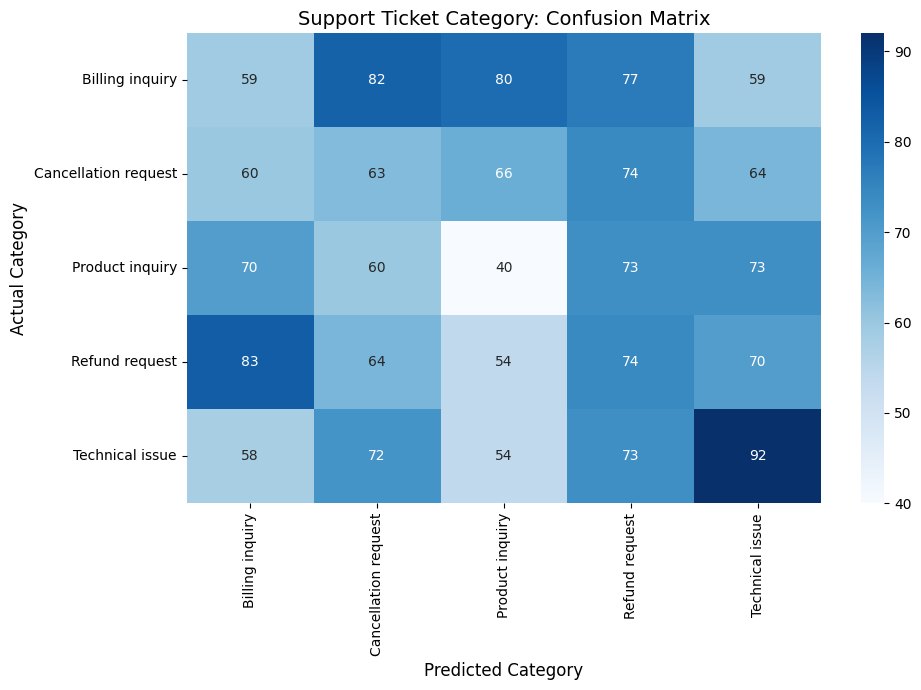

In [5]:
# Make predictions on the test set
cat_preds = cat_model.predict(X_test)
pri_preds = pri_model.predict(X_test)

# Print standard text reports
print("--- CATEGORY CLASSIFICATION REPORT ---")
print(classification_report(y_cat_test, cat_preds))

print("\n--- PRIORITY CLASSIFICATION REPORT ---")
print(classification_report(y_pri_test, pri_preds))

# --- Plot the Confusion Matrix for Categories ---
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_cat_test, cat_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_model.classes_,
            yticklabels=cat_model.classes_)

plt.title('Support Ticket Category: Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.tight_layout()

# Save the visualization for GitHub/LinkedIn
plt.savefig('ticket_classification_matrix.png', dpi=300)
plt.show()

In [6]:
# --- THE LIVE TEST SCRIPT ---

def predict_ticket(custom_ticket_text):
    # 1. Clean the text exactly like we did for the training data
    cleaned_text = clean_text(custom_ticket_text)

    # 2. Convert the text to numbers using our trained TF-IDF vectorizer
    vectorized_text = vectorizer.transform([cleaned_text])

    # 3. Make predictions using both models
    predicted_category = cat_model.predict(vectorized_text)[0]
    predicted_priority = pri_model.predict(vectorized_text)[0]

    # 4. Print the results clearly
    print("\n" + "="*40)
    print("🎫 NEW TICKET RECEIVED")
    print("="*40)
    print(f"Message: '{custom_ticket_text}'\n")
    print(f"➡️  ROUTING TO: {predicted_category.upper()} TEAM")
    print(f"🚨  PRIORITY LEVEL: {predicted_priority.upper()}")
    print("="*40 + "\n")

# Try testing it with a few different scenarios!
predict_ticket("I was charged twice for my subscription this month. Please refund the extra $15 immediately.")
predict_ticket("How do I update my profile picture?")
predict_ticket("THE ENTIRE SERVER IS DOWN AND WE CANNOT ACCESS OUR DATA. FIX THIS NOW.")


🎫 NEW TICKET RECEIVED
Message: 'I was charged twice for my subscription this month. Please refund the extra $15 immediately.'

➡️  ROUTING TO: CANCELLATION REQUEST TEAM
🚨  PRIORITY LEVEL: MEDIUM


🎫 NEW TICKET RECEIVED
Message: 'How do I update my profile picture?'

➡️  ROUTING TO: TECHNICAL ISSUE TEAM
🚨  PRIORITY LEVEL: MEDIUM


🎫 NEW TICKET RECEIVED
Message: 'THE ENTIRE SERVER IS DOWN AND WE CANNOT ACCESS OUR DATA. FIX THIS NOW.'

➡️  ROUTING TO: TECHNICAL ISSUE TEAM
🚨  PRIORITY LEVEL: MEDIUM

